# UTS - Analisis Clustering Aksara Jawa

## Import Library 

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Load Data Citra Aksara Jawa

In [25]:
DATA_FOLDER = 'DATA UTS2'   # Ganti jika perlu
IMG_SIZE    = 64

images      = []
filenames   = []
labels_src  = []   # Nama kontributor (ANDREW / IUS / PITA)

for fname in sorted(os.listdir(DATA_FOLDER)):
    if fname.lower().endswith('.png'):
        path = os.path.join(DATA_FOLDER, fname)
        img  = Image.open(path).convert('L')          # Grayscale
        img  = img.resize((IMG_SIZE, IMG_SIZE))        # Pastikan 64×64
        arr  = np.array(img, dtype=np.float32) / 255.0
        images.append(arr)
        filenames.append(fname)
        labels_src.append(fname.split('_')[0])

images     = np.array(images)      # Shape: (N, 64, 64)
labels_src = np.array(labels_src)
N          = len(images)

print(f'   Total citra dimuat   : {N}')
print(f'   Dimensi dataset      : {images.shape}')
print(f'   Label Data           : {np.unique(labels_src)}')
for src in np.unique(labels_src):
    print(f'   - {src}: {np.sum(labels_src == src)} gambar')

   Total citra dimuat   : 57
   Dimensi dataset      : (57, 64, 64)
   Label Data           : ['ANDREW' 'IUS' 'PITA']
   - ANDREW: 20 gambar
   - IUS: 18 gambar
   - PITA: 19 gambar


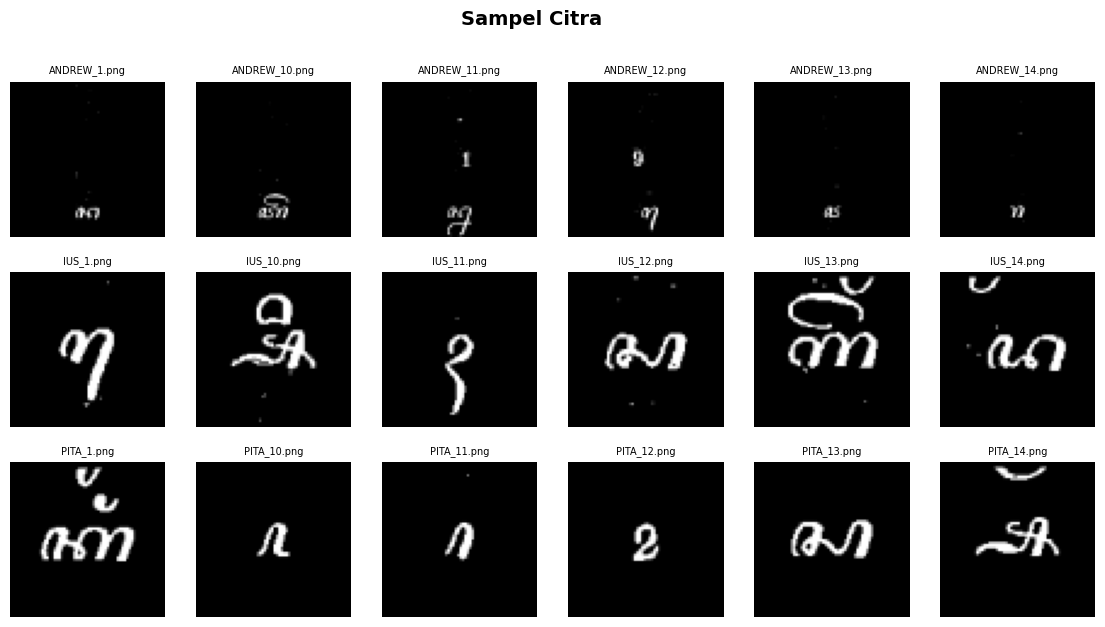

In [26]:
# Menampikan sampel citra dari masing-masing kontributor
fig, axes = plt.subplots(3, 6, figsize=(14, 7))
fig.suptitle('Sampel Citra ', fontsize=14, fontweight='bold')

for row_idx, src in enumerate(np.unique(labels_src)):
    idxs = np.where(labels_src == src)[0][:6]
    for col_idx, idx in enumerate(idxs):
        axes[row_idx, col_idx].imshow(images[idx], cmap='gray')
        axes[row_idx, col_idx].set_title(filenames[idx], fontsize=7)
        axes[row_idx, col_idx].axis('off')
    axes[row_idx, 0].set_ylabel(src, fontsize=11, fontweight='bold', rotation=0, labelpad=50)

## Aktivitas 2 – Representasi Fitur (F2)

### F2.1 – Transformasi Data: Flatten & PCA

In [27]:
# STEP 1: Flatten 64×64 
X_flat = images.reshape(N, -1)   # Shape: (N, 4096)
dim_awal = X_flat.shape[1]

print(f'Dimensi awal (setelah flatten) : {X_flat.shape}  →  {dim_awal} fitur per sampel')

# Standarisasi sebelum PCA 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

# STEP 2: PCA 
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1

# PCA final
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

dim_pca = X_pca.shape[1]

print(f'\nTransformasi Data')
print(f'{"Parameter":<30} {"Nilai"}')
print('-' * 45)
print(f'{"Dimensi awal":<30} {dim_awal}')
print(f'{"Dimensi setelah PCA":<30} {dim_pca}')
print(f'{"Variance tertangkap":<30} {cumvar[n_components_95-1]*100:.2f}%')
print(f'{"Reduksi dimensi":<30} {((dim_awal - dim_pca) / dim_awal * 100):.1f}%')

Dimensi awal (setelah flatten) : (57, 4096)  →  4096 fitur per sampel

Transformasi Data
Parameter                      Nilai
---------------------------------------------
Dimensi awal                   4096
Dimensi setelah PCA            29
Variance tertangkap            95.16%
Reduksi dimensi                99.3%


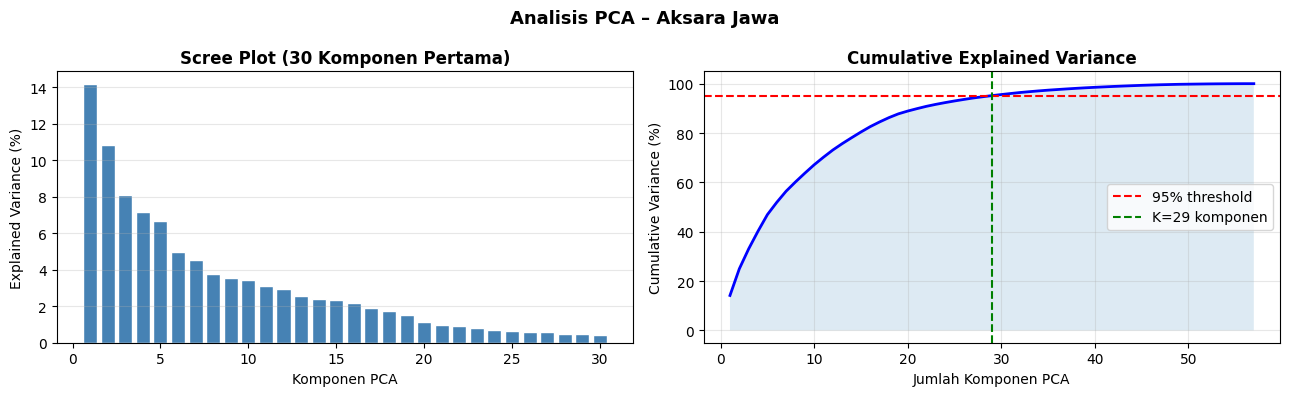

In [28]:
# Visualisasi 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))


axes[0].bar(range(1, min(31, len(pca_full.explained_variance_ratio_)+1)),
            pca_full.explained_variance_ratio_[:30] * 100,
            color='steelblue', edgecolor='white')
axes[0].set_title('Scree Plot (30 Komponen Pertama)', fontweight='bold')
axes[0].set_xlabel('Komponen PCA')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].grid(axis='y', alpha=0.3)


axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, 'b-', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].axvline(n_components_95, color='green', linestyle='--',
                label=f'K={n_components_95} komponen')
axes[1].fill_between(range(1, len(cumvar)+1), cumvar * 100, alpha=0.15)
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Jumlah Komponen PCA')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Analisis PCA – Aksara Jawa', fontsize=13, fontweight='bold')
plt.tight_layout()

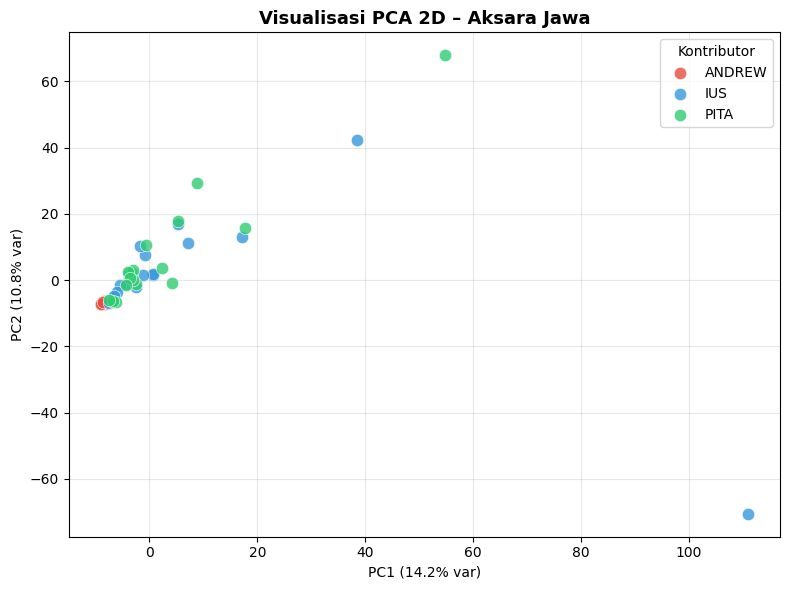

In [29]:
# Visualisasi 2D PCA space
fig, ax = plt.subplots(figsize=(8, 6))
colors = {'ANDREW': '#e74c3c', 'IUS': '#3498db', 'PITA': '#2ecc71'}
for src in np.unique(labels_src):
    mask = labels_src == src
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=src, color=colors.get(src, 'gray'),
               s=80, alpha=0.8, edgecolors='white', linewidths=0.5)
ax.set_title('Visualisasi PCA 2D – Aksara Jawa', fontweight='bold', fontsize=13)
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend(title='Kontributor')
ax.grid(alpha=0.3)
plt.tight_layout()

## Aktivitas 3 – Clustering dengan K-Means (G3)

### G3.1 & G3.2 – Eksperimen dan Hasil Inertia

In [30]:
# Eksperimen K-Means dengan K = 5, 10, 20 dan Elbow Method untuk rentang K yang lebih luas

K_values       = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]
inertia_values = {}
silhouette_vals= {}
kmeans_models  = {}

print(f'{"K":>4} {"Inertia":>12} {"Silhouette":>12}')
print('-' * 32)

for k in K_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    labels = km.fit_predict(X_pca)
    inertia = km.inertia_
    sil = silhouette_score(X_pca, labels) if k > 1 else 0.0

    inertia_values[k] = inertia
    silhouette_vals[k] = sil
    kmeans_models[k]  = km
    print(f'{k:>4} {inertia:>12.2f} {sil:>12.4f}')

print('\nHasil Inertia ')
print(f'{"K":<6} {"Inertia":>12}')
print('-' * 20)
for k in [5, 10, 20]:
    print(f'{k:<6} {inertia_values[k]:>12.2f}')

   K      Inertia   Silhouette
--------------------------------
   2    113893.62       0.5999
   3    101113.30       0.5459
   4     94804.09       0.4668
   5     84029.22       0.2662
   6     73225.29       0.4835
   7     67255.95       0.4238
   8     59560.19       0.2466
  10     50546.81       0.2635
  12     41165.96       0.2476
  15     28745.94       0.2574
  20     12918.09       0.3164

Hasil Inertia 
K           Inertia
--------------------
5          84029.22
10         50546.81
20         12918.09


### G3.3 – Analisis Elbow Method

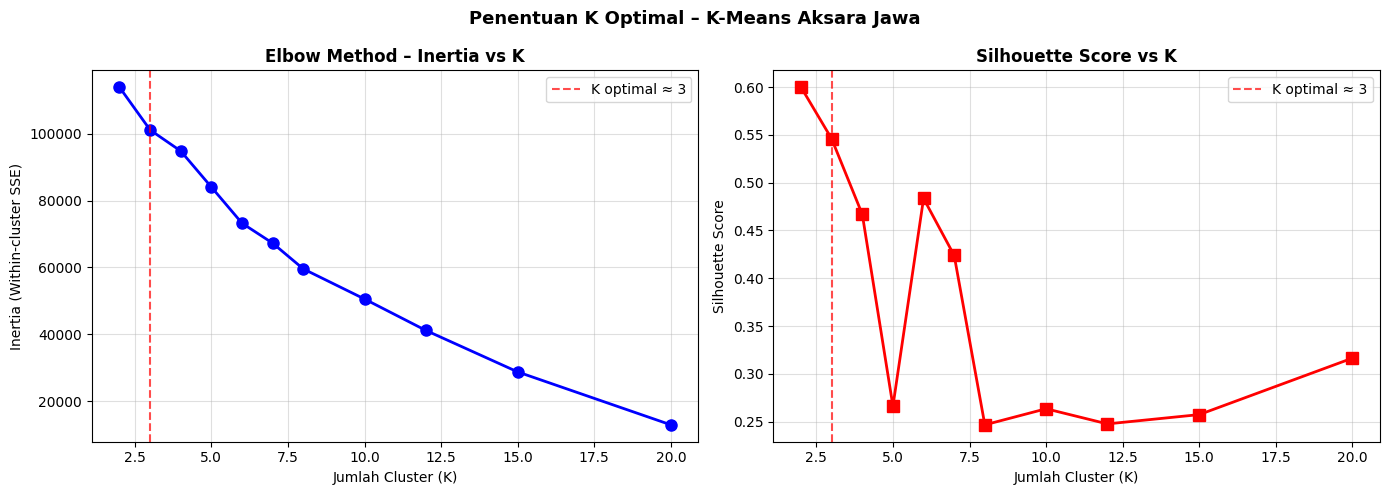

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
ks  = sorted(inertia_values.keys())
ins = [inertia_values[k] for k in ks]
sils= [silhouette_vals[k] for k in ks]

axes[0].plot(ks, ins, 'bo-', markersize=8, linewidth=2)
axes[0].set_title('Elbow Method – Inertia vs K', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].grid(alpha=0.4)

# Menandai titik elbow 
# Heuristic: titik dengan penurunan inertia paling landai
diffs  = np.diff(ins)
diffs2 = np.diff(diffs)
elbow_idx = np.argmax(diffs2) + 1  
k_optimal = ks[elbow_idx]

axes[0].axvline(k_optimal, color='red', linestyle='--', alpha=0.7,
                label=f'K optimal ≈ {k_optimal}')
axes[0].legend()

# Silhouette Score
axes[1].plot(ks, sils, 'rs-', markersize=8, linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(k_optimal, color='red', linestyle='--', alpha=0.7,
                label=f'K optimal ≈ {k_optimal}')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.suptitle('Penentuan K Optimal – K-Means Aksara Jawa', fontsize=13, fontweight='bold')
plt.tight_layout()

## Aktivitas 4 – Analisis Visual Cluster (H4)

Tampilkan minimal 5 gambar per cluster menggunakan K optimal.

In [32]:
# Gunakan K optimal
km_opt = kmeans_models[k_optimal]
cluster_labels = km_opt.labels_

print(f'Menggunakan K = {k_optimal} cluster')
print('Distribusi anggota per cluster:')
for c in range(k_optimal):
    mask = cluster_labels == c
    fnames_in = [filenames[i] for i in np.where(mask)[0]]
    print(f'  Cluster {c}: {sum(mask):>3} gambar  | {fnames_in[:4]}')

Menggunakan K = 3 cluster
Distribusi anggota per cluster:
  Cluster 0:  55 gambar  | ['ANDREW_1.png', 'ANDREW_10.png', 'ANDREW_11.png', 'ANDREW_12.png']
  Cluster 1:   1 gambar  | ['IUS_17.png']
  Cluster 2:   1 gambar  | ['PITA_19.png']


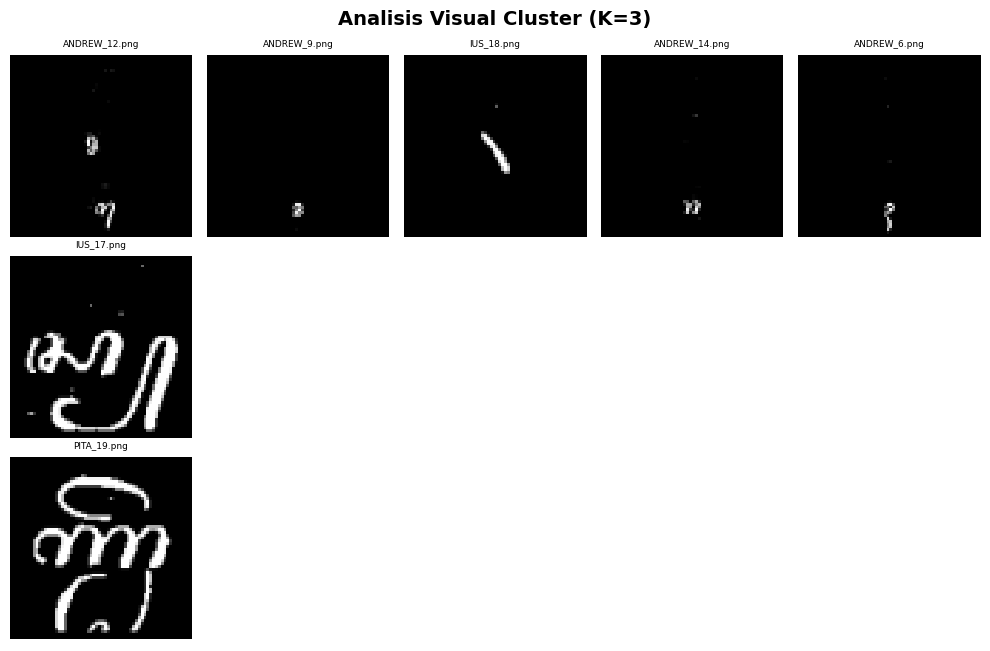

In [33]:
# Tampilkan 5 gambar dari setiap cluster

N_SHOW = 5
K = k_optimal

fig, axes = plt.subplots(K, N_SHOW, figsize=(N_SHOW * 2, K * 2.2))
fig.suptitle(f'Analisis Visual Cluster (K={K})', fontsize=14, fontweight='bold')

if K == 1:
    axes = axes[np.newaxis, :]

for c in range(K):
    idxs_in_cluster = np.where(cluster_labels == c)[0]
    # Urutkan berdasarkan jarak ke centroid (yang terdekat dulu)
    dists = np.linalg.norm(X_pca[idxs_in_cluster] - km_opt.cluster_centers_[c], axis=1)
    sorted_idxs = idxs_in_cluster[np.argsort(dists)]
    show_idxs = sorted_idxs[:N_SHOW]

    for col, idx in enumerate(show_idxs):
        ax = axes[c, col]
        ax.imshow(images[idx], cmap='gray', interpolation='nearest')
        ax.set_title(filenames[idx], fontsize=6.5)
        ax.axis('off')

    # Isi kolom kosong jika anggota < N_SHOW
    for col in range(len(show_idxs), N_SHOW):
        axes[c, col].axis('off')

    axes[c, 0].set_ylabel(f'C{c}\n({len(idxs_in_cluster)} img)',
                          fontsize=9, fontweight='bold', rotation=0, labelpad=50)

plt.tight_layout()

In [34]:
# H4.1 – Observasi tiap cluster

print('=' * 60)
print('H4.1 – OBSERVASI PER CLUSTER')
print('=' * 60)

for c in range(K):
    mask = cluster_labels == c
    members = [filenames[i] for i in np.where(mask)[0]]
    contributors = [m.split('_')[0] for m in members]
    unique_contrib = set(contributors)

    # Hitung dominansi pixel (apakah gelap/terang)
    cluster_imgs  = images[mask]
    avg_brightness = cluster_imgs.mean()
    std_brightness = cluster_imgs.std()

    print(f'\nCluster {c}:')
    print(f'  Jumlah gambar      : {sum(mask)}')
    print(f'  Kontributor      : {unique_contrib}')
    print(f'  Rata-Rata brightness  : {avg_brightness:.3f}  (0=hitam, 1=putih)')
    print(f'  Std brightness     : {std_brightness:.3f}')
    print(f'  Gambar           : {members}')

H4.1 – OBSERVASI PER CLUSTER

Cluster 0:
  Jumlah gambar      : 55
  Kontributor      : {'IUS', 'ANDREW', 'PITA'}
  Rata-Rata brightness  : 0.038  (0=hitam, 1=putih)
  Std brightness     : 0.174
  Gambar           : ['ANDREW_1.png', 'ANDREW_10.png', 'ANDREW_11.png', 'ANDREW_12.png', 'ANDREW_13.png', 'ANDREW_14.png', 'ANDREW_15.png', 'ANDREW_16.png', 'ANDREW_17.png', 'ANDREW_18.png', 'ANDREW_19.png', 'ANDREW_2.png', 'ANDREW_20.png', 'ANDREW_3.png', 'ANDREW_4.png', 'ANDREW_5.png', 'ANDREW_6.png', 'ANDREW_7.png', 'ANDREW_8.png', 'ANDREW_9.png', 'IUS_1.png', 'IUS_10.png', 'IUS_11.png', 'IUS_12.png', 'IUS_13.png', 'IUS_14.png', 'IUS_15.png', 'IUS_16.png', 'IUS_18.png', 'IUS_2.png', 'IUS_3.png', 'IUS_4.png', 'IUS_5.png', 'IUS_6.png', 'IUS_7.png', 'IUS_8.png', 'IUS_9.png', 'PITA_1.png', 'PITA_10.png', 'PITA_11.png', 'PITA_12.png', 'PITA_13.png', 'PITA_14.png', 'PITA_15.png', 'PITA_16.png', 'PITA_17.png', 'PITA_18.png', 'PITA_2.png', 'PITA_3.png', 'PITA_4.png', 'PITA_5.png', 'PITA_6.png', 'PIT

## Aktivitas 5 – Evaluasi Clustering (I5)

### I5.1 – Evaluasi 

In [35]:
# Evaluasi untuk K optimal
sil_score = silhouette_score(X_pca, cluster_labels)
inertia   = km_opt.inertia_

print('=' * 50)
print('TABEL I5.1 – Evaluasi Internal')
print('=' * 50)
print(f'{"Metrik":<25} {"Nilai"}')
print('-' * 40)
print(f'{"Silhouette Score":<25} {sil_score:.4f}')
print(f'{"Inertia":<25} {inertia:.4f}')
print(f'{"K Optimal":<25} {k_optimal}')
print(f'{"Jumlah Sampel":<25} {N}')
print(f'{"Dimensi PCA":<25} {dim_pca}')

# Interpretasi silhouette
if sil_score >= 0.7:
    interp = 'Sangat baik (struktur cluster kuat)'
elif sil_score >= 0.5:
    interp = 'Baik (struktur cluster cukup jelas)'
elif sil_score >= 0.25:
    interp = 'Sedang (cluster kurang terpisah dengan baik)'
else:
    interp = 'Lemah (data mungkin tidak memiliki struktur cluster yang jelas)'

print(f'\nInterpretasi Silhouette Score = {sil_score:.4f}')
print(f'   → {interp}')

TABEL I5.1 – Evaluasi Internal
Metrik                    Nilai
----------------------------------------
Silhouette Score          0.5459
Inertia                   101113.2969
K Optimal                 3
Jumlah Sampel             57
Dimensi PCA               29

Interpretasi Silhouette Score = 0.5459
   → Baik (struktur cluster cukup jelas)


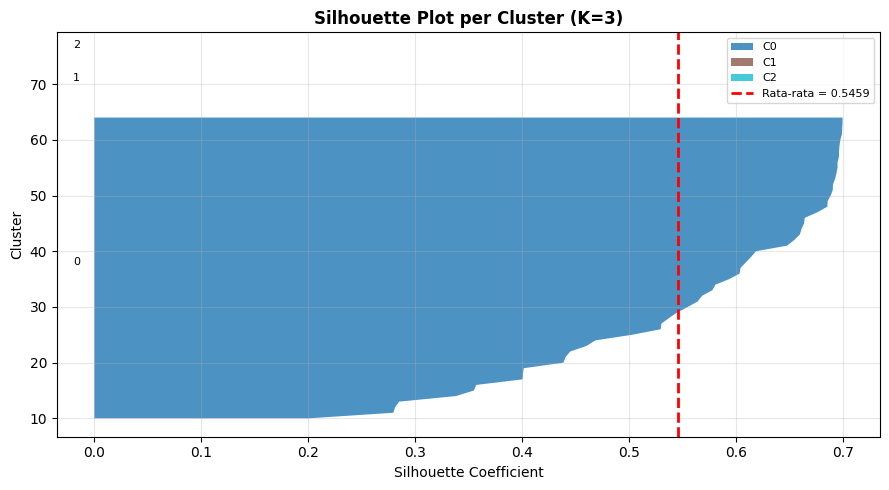

In [36]:
# Silhouette plot per sampel
from sklearn.metrics import silhouette_samples

sil_samples = silhouette_samples(X_pca, cluster_labels)

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
cmap    = plt.cm.get_cmap('tab10', K)

for c in range(K):
    vals = sorted(sil_samples[cluster_labels == c])
    size = len(vals)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=cmap(c), alpha=0.8, label=f'C{c}')
    ax.text(-0.02, y_lower + size / 2, str(c), fontsize=8)
    y_lower = y_upper + 5

ax.axvline(sil_score, color='red', linestyle='--', linewidth=2,
           label=f'Rata-rata = {sil_score:.4f}')
ax.set_title(f'Silhouette Plot per Cluster (K={K})', fontweight='bold', fontsize=12)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()

##  Aktivitas 6 – Clustering sebagai Dasar Klasifikasi (J6)

### J6.1 – Mapping Cluster ke Label

In [ ]:
# Mapping cluster 

# Aksara Jawa dasar
aksara_jawa = ['ha','na','ca','ra','ka','da','ta','sa','wa','la',
               'pa','dha','ja','ya','nya','ma','ga','ba','tha','nga']

# Pilih 3 cluster untuk dianalisis 
focus_clusters = list(range(min(3, K)))

print('TABEL J6.1 – Mapping Cluster ke Label Dugaan')
print('=' * 60)
print(f'{"Cluster":<10} {"Jumlah":<8} {"Kontributor":<20} {"Dugaan Label"}')
print('-' * 60)

cluster_to_label = {}
for c in range(K):
    mask    = cluster_labels == c
    members = [filenames[i] for i in np.where(mask)[0]]
    contribs= list(set([m.split('_')[0] for m in members]))
    # Nomor gambar 
    nums    = [int(m.split('_')[1].split('.')[0]) for m in members]
    avg_num = int(np.mean(nums))
    # Dugaan label berdasarkan rata-rata nomor
    label   = aksara_jawa[(avg_num - 1) % len(aksara_jawa)]
    cluster_to_label[c] = label

    mark = ' ← FOKUS' if c in focus_clusters else ''
    print(f'C{c:<9} {sum(mask):<8} {str(contribs):<20} {label}{mark}')

TABEL J6.1 – Mapping Cluster ke Label Dugaan
Cluster    Jumlah   Kontributor          Dugaan Label
------------------------------------------------------------
C0         55       ['IUS', 'ANDREW', 'PITA'] wa ← FOKUS
C1         1        ['IUS']              ga ← FOKUS
C2         1        ['PITA']             tha ← FOKUS


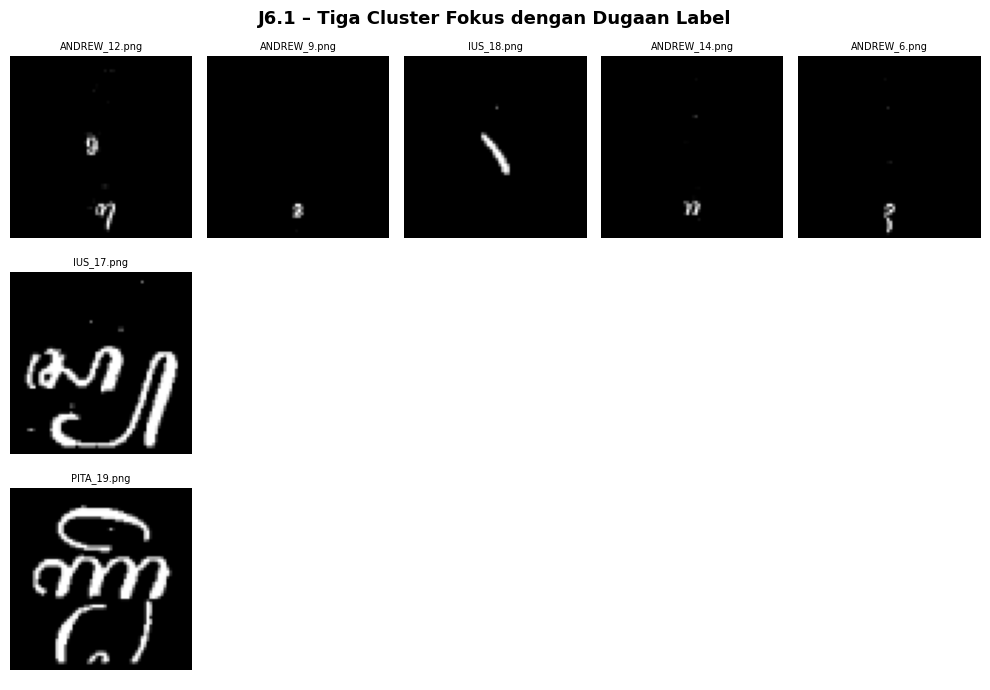

In [38]:
# Visualisasi 3 cluster fokus
fig, axes = plt.subplots(3, N_SHOW, figsize=(N_SHOW * 2, 7))
fig.suptitle('J6.1 – Tiga Cluster Fokus dengan Dugaan Label', fontsize=13, fontweight='bold')

for row, c in enumerate(focus_clusters):
    idxs  = np.where(cluster_labels == c)[0]
    dists = np.linalg.norm(X_pca[idxs] - km_opt.cluster_centers_[c], axis=1)
    sorted_idxs = idxs[np.argsort(dists)][:N_SHOW]

    for col, idx in enumerate(sorted_idxs):
        axes[row, col].imshow(images[idx], cmap='gray')
        axes[row, col].set_title(filenames[idx], fontsize=7)
        axes[row, col].axis('off')
    for col in range(len(sorted_idxs), N_SHOW):
        axes[row, col].axis('off')

    axes[row, 0].set_ylabel(
        f'C{c}\nDugaan: {cluster_to_label[c]}',
        fontsize=9, fontweight='bold', rotation=0, labelpad=70
    )

plt.tight_layout()

## 💡 Aktivitas 7 – Refleksi Analitis (K7)

In [39]:
# Statistik 
print(f'Total data      : {N} gambar')
print(f'Kontributor     : {np.unique(labels_src)}')
print(f'Dimensi awal    : {dim_awal}')
print(f'Dimensi PCA     : {dim_pca} (variance tertangkap 95%)')
print(f'K optimal       : {k_optimal}')
print(f'Silhouette Score: {sil_score:.4f}')
print(f'Inertia final   : {inertia:.2f}')

Total data      : 57 gambar
Kontributor     : ['ANDREW' 'IUS' 'PITA']
Dimensi awal    : 4096
Dimensi PCA     : 29 (variance tertangkap 95%)
K optimal       : 3
Silhouette Score: 0.5459
Inertia final   : 101113.30


## Perbandingan dengan Metode Lain

In [40]:
# BONUS 1: K-Means TANPA PCA 
km_nopca = KMeans(n_clusters=k_optimal, random_state=RANDOM_STATE, n_init=10)
labels_nopca = km_nopca.fit_predict(X_scaled)
sil_nopca    = silhouette_score(X_scaled, labels_nopca)

print(f'   Silhouette Score (tanpa PCA) : {sil_nopca:.4f}')
print(f'   Silhouette Score (dengan PCA): {sil_score:.4f}')
print(f'   PCA lebih baik: {"YA" if sil_score > sil_nopca else "TIDAK"}')

   Silhouette Score (tanpa PCA) : 0.5151
   Silhouette Score (dengan PCA): 0.5459
   PCA lebih baik: YA


In [41]:
# ============================================================
# BONUS 2: Agglomerative Clustering
# ============================================================
print('Agglomerative Clustering')
for linkage in ['ward', 'complete', 'average']:
    agg = AgglomerativeClustering(n_clusters=k_optimal, linkage=linkage)
    labels_agg = agg.fit_predict(X_pca)
    sil_agg    = silhouette_score(X_pca, labels_agg)
    print(f'   Linkage={linkage:<10} Silhouette: {sil_agg:.4f}')

Agglomerative Clustering
   Linkage=ward       Silhouette: 0.5050
   Linkage=complete   Silhouette: 0.5459
   Linkage=average    Silhouette: 0.5459


In [42]:
# BONUS 3: DBSCAN
# Grid search sederhana untuk eps
from sklearn.neighbors import NearestNeighbors

# Estimasi eps dari k-distance graph
nn = NearestNeighbors(n_neighbors=3).fit(X_pca)
dists, _ = nn.kneighbors(X_pca)
dists_sorted = np.sort(dists[:, -1])[::-1]

best_sil_dbscan = -1
best_eps        = 0
best_labels_db  = None

for eps_val in np.arange(0.5, 5.0, 0.3):
    db = DBSCAN(eps=eps_val, min_samples=2)
    labels_db = db.fit_predict(X_pca)
    n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise       = sum(labels_db == -1)
    if n_clusters_db >= 2 and n_clusters_db <= 15:
        valid_mask = labels_db != -1
        if sum(valid_mask) > 10:
            sil_db = silhouette_score(X_pca[valid_mask], labels_db[valid_mask])
            if sil_db > best_sil_dbscan:
                best_sil_dbscan = sil_db
                best_eps        = eps_val
                best_labels_db  = labels_db

if best_labels_db is not None:
    n_cl = len(set(best_labels_db)) - (1 if -1 in best_labels_db else 0)
    n_no = sum(best_labels_db == -1)
    print(f'   DBSCAN terbaik: eps={best_eps:.1f}, K={n_cl}, noise={n_no}, Silhouette={best_sil_dbscan:.4f}')
else:
    print('   DBSCAN: tidak ditemukan konfigurasi valid (data terlalu kecil/dense)')

   DBSCAN terbaik: eps=3.8, K=2, noise=42, Silhouette=0.8191


In [43]:
# ============================================================
# BONUS: Tabel Perbandingan Final
# ============================================================
agg_ward = AgglomerativeClustering(n_clusters=k_optimal, linkage='ward')
labels_agg_ward = agg_ward.fit_predict(X_pca)
sil_agg_ward = silhouette_score(X_pca, labels_agg_ward)

print('\nTABEL  – Perbandingan Metode Clustering')
print('=' * 60)
print(f'{"Metode":<30} {"K":<6} {"Silhouette":>12}')
print('-' * 50)
print(f'{"K-Means + PCA":<30} {k_optimal:<6} {sil_score:>12.4f}')
print(f'{"K-Means (tanpa PCA)":<30} {k_optimal:<6} {sil_nopca:>12.4f}')
print(f'{"Agglomerative (ward)":<30} {k_optimal:<6} {sil_agg_ward:>12.4f}')
if best_labels_db is not None:
    print(f'{"DBSCAN (best eps)":<30} {n_cl:<6} {best_sil_dbscan:>12.4f}')
print('=' * 60)


TABEL  – Perbandingan Metode Clustering
Metode                         K        Silhouette
--------------------------------------------------
K-Means + PCA                  3            0.5459
K-Means (tanpa PCA)            3            0.5151
Agglomerative (ward)           3            0.5050
DBSCAN (best eps)              2            0.8191


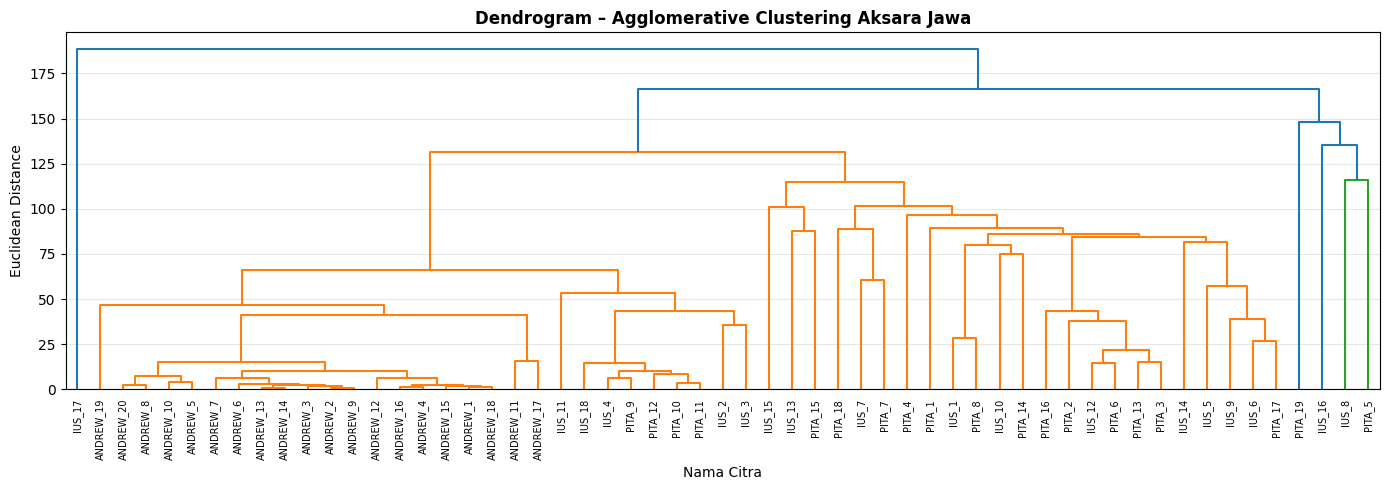

In [44]:
# Visualisasi Dendrogram (Agglomerative)
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage

Z = scipy_linkage(X_pca, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax,
           labels=[f.replace('.png','') for f in filenames],
           leaf_rotation=90, leaf_font_size=7,
           color_threshold=0.7 * max(Z[:, 2]))
ax.set_title('Dendrogram – Agglomerative Clustering Aksara Jawa', fontweight='bold', fontsize=12)
ax.set_xlabel('Nama Citra')
ax.set_ylabel('Euclidean Distance')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
